In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv("Electric Vehicle Sales by State in India (1).csv")


In [4]:
# Display first few rows
print(df.head())

     Year Month_Name      Date           State         Vehicle_Class  \
0  2014.0        jan  1/1/2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014.0        jan  1/1/2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014.0        jan  1/1/2014  Andhra Pradesh             AMBULANCE   
3  2014.0        jan  1/1/2014  Andhra Pradesh   ARTICULATED VEHICLE   
4  2014.0        jan  1/1/2014  Andhra Pradesh                   BUS   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           Others       Others                0.0  
1           Others       Others                0.0  
2           Others       Others                0.0  
3           Others       Others                0.0  
4              Bus          Bus                0.0  


In [5]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [6]:
# Check for missing values
print("Missing values before filling:\n", df.isnull().sum())


Missing values before filling:
 Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64


In [7]:
# Set visualization style
sns.set(style='whitegrid', palette='deep')

# EV sales by state over years

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


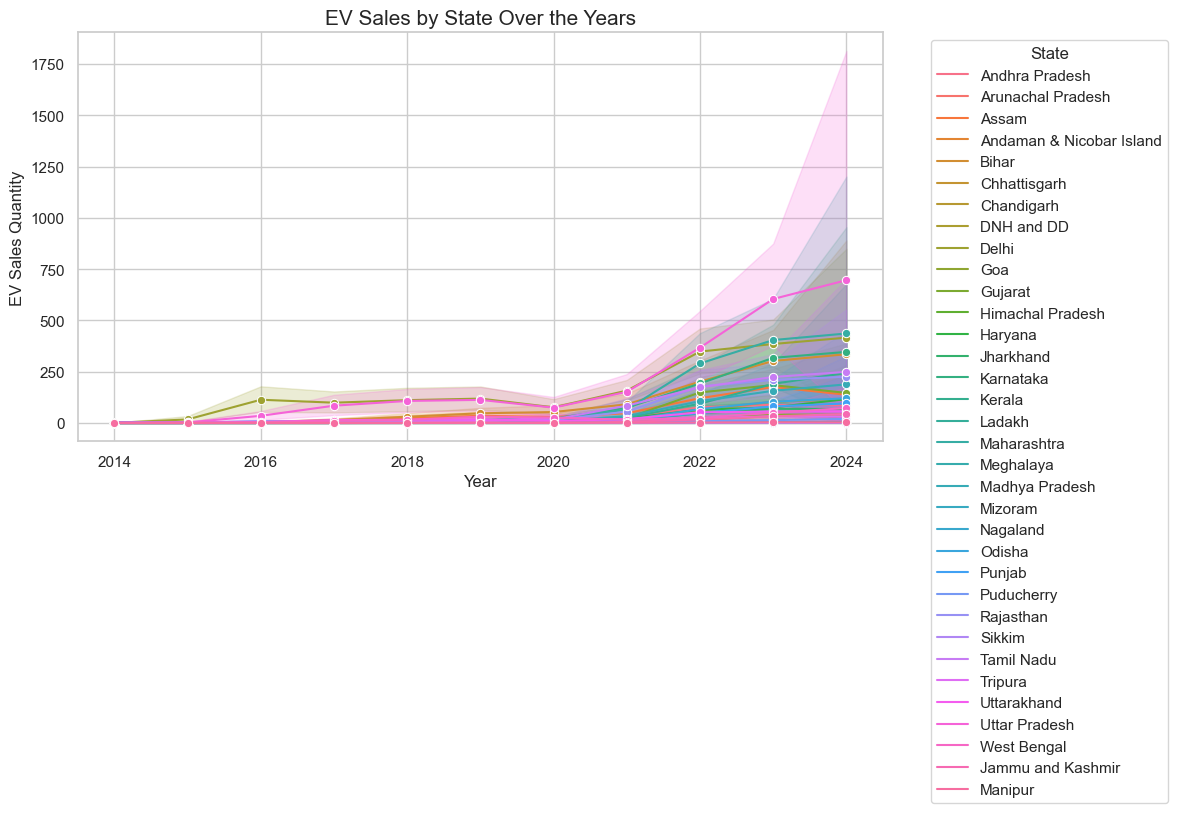

In [10]:
# EV Sales by State Over the Years
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='Year', y='EV_Sales_Quantity', hue='State', marker='o')
plt.title('EV Sales by State Over the Years', fontsize=15)
plt.xlabel('Year')
plt.ylabel('EV Sales Quantity')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()   

# EV sales by vehicle category

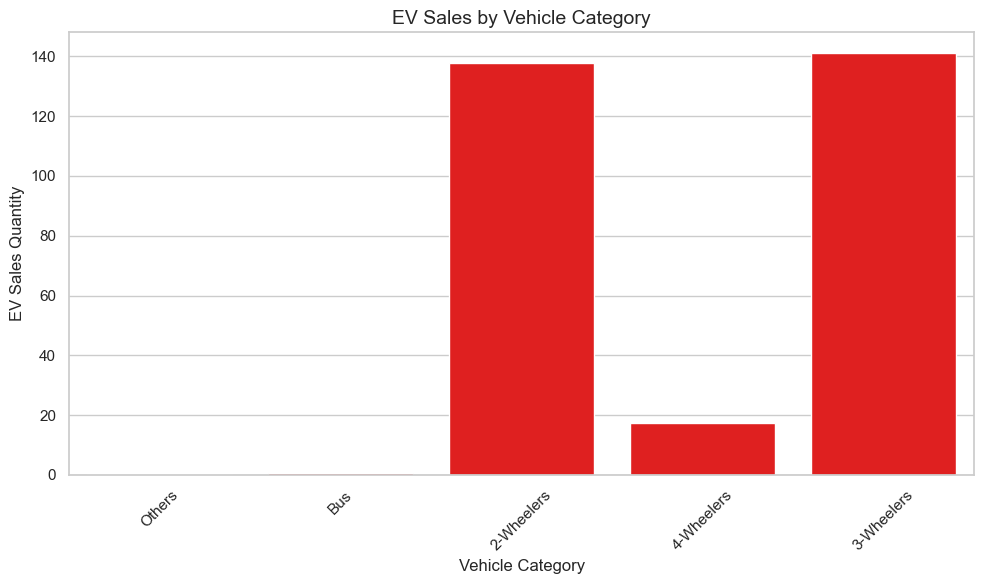

In [11]:
# EV Sales by Vehicle Category
plt.figure(figsize=(10, 6))
sns.barplot(x='Vehicle_Category', y='EV_Sales_Quantity', data=df, errorbar=None, color='red')
plt.title('EV Sales by Vehicle Category', fontsize=14)
plt.xlabel('Vehicle Category')
plt.ylabel('EV Sales Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Top 10 States with Highest EV Sales

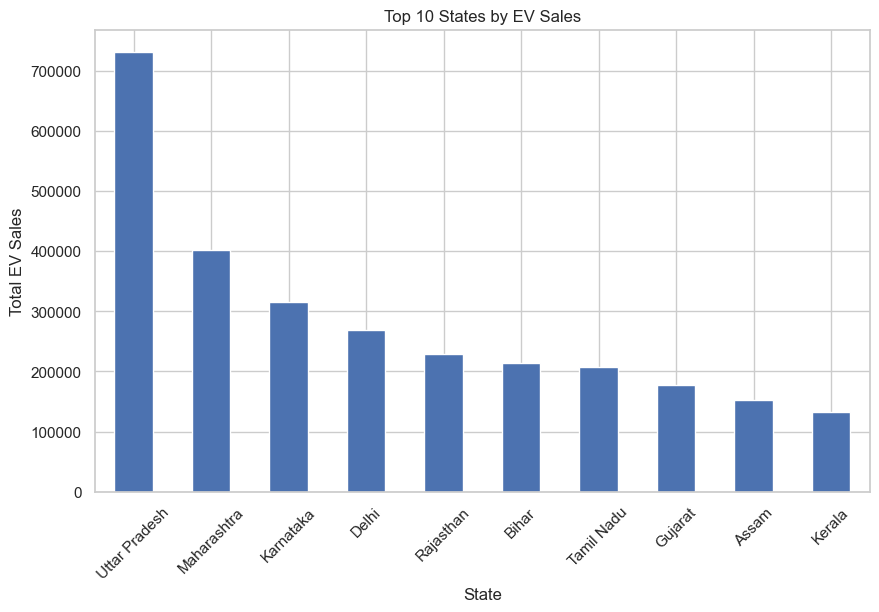

In [12]:
top_states = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title("Top 10 States by EV Sales")
plt.xlabel("State")
plt.ylabel("Total EV Sales")
plt.xticks(rotation=45)
plt.show()

# EV Sales Distribution (Box Plot)

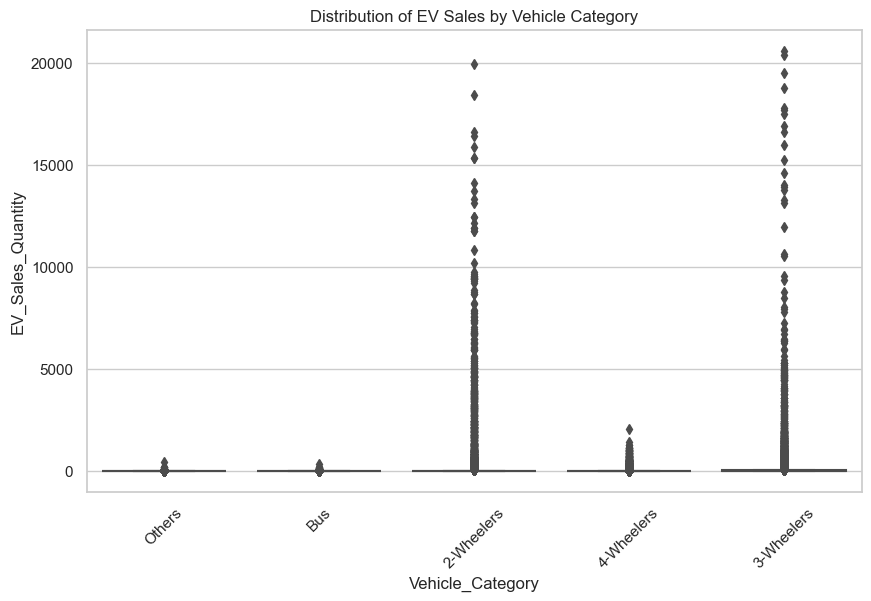

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Vehicle_Category', y='EV_Sales_Quantity', data=df)
plt.title("Distribution of EV Sales by Vehicle Category")
plt.xticks(rotation=45)
plt.show()

# EV Market Share by Vehicle Category

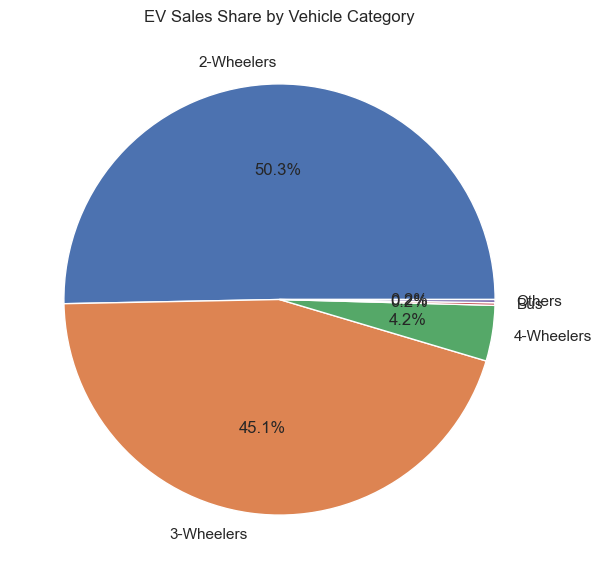

In [17]:
category_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum()

plt.figure(figsize=(7,7))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')
plt.title("EV Sales Share by Vehicle Category")
plt.show()

# Correlation Heatmap